# Torch Batteries Example: CIFAR-10 Transfer Learning

This notebook adapts a pretrained ResNet18 to CIFAR-10. A frozen classification-head phase is followed by progressive unfreezing, then the complete training state is saved, restored, and resumed in fresh `Battery` instances.

## What this notebook demonstrates

- a resumable custom `Callback`
- weighted batch-callable, incremental `StatefulMetric`, and full-phase `CollectedMetric` metrics
- `ReduceLROnPlateau` through `LearningRateScheduler`
- top-k `ModelCheckpoint` files containing complete training state
- explicit checkpoint saving and loading
- total and additional resume epoch semantics
- strict raw model-weight detection
- structured prediction with `move_to_cpu` and `concatenate`

[Checkpoint guide](https://michalszc.github.io/torch-batteries/guides/checkpoints/) · [Metrics guide](https://michalszc.github.io/torch-batteries/guides/metrics/) · [Prediction guide](https://michalszc.github.io/torch-batteries/guides/prediction/)

## 0. Prerequisites

Use Python 3.12 or newer. The next cell installs torch-batteries and the `example`
dependencies into the active notebook environment. Restart the kernel if the
notebook application asks you to do so after installation.

Torchvision downloads CIFAR-10 (about 170 MB) and ResNet18 weights (about 45 MB) on
the first run. This transfer-learning workload uses 96×96 images and several
training and resume phases, so CUDA or MPS is recommended; CPU execution can take
considerably longer. Checkpoints are written below `checkpoints/cifar10-transfer/`.

In [ ]:
%pip install "torch-batteries[example]"

## 1. Setup and reproducibility

All datasets, pretrained weights, and checkpoints are downloaded or created by notebook code. The checkpoint directory is dedicated to this example and is cleared at the beginning so top-k results are reproducible.

In [1]:
import random
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import f1_score
from torch import nn
from torch.nn import functional as nn_functional
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights

import torch_batteries
from torch_batteries import (
    Battery,
    CollectedMetric,
    Event,
    EventContext,
    StepOutput,
    charge,
)
from torch_batteries.callbacks import (
    Callback,
    LearningRateScheduler,
    ModelCheckpoint,
)

SEED = 42
BATCH_SIZE = 64
TRAIN_SAMPLES = 5_000
VALIDATION_SAMPLES = 1_000
TEST_SAMPLES = 1_000
INITIAL_EPOCHS = 3
DATA_ROOT = Path("./data")
CHECKPOINT_DIR = Path("./checkpoints/cifar10-transfer")

random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
shutil.rmtree(CHECKPOINT_DIR, ignore_errors=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"torch-batteries: {torch_batteries.__version__}")
print(f"Device: {DEVICE}")

torch-batteries: 0.11.0
Device: mps


## 2. Download and prepare CIFAR-10

The pretrained ResNet18 normalization is retained, while images are resized to `96 × 96` to keep this educational run practical. Training uses random horizontal flips; validation and test data remain deterministic. Fixed subset indices make repeated runs comparable.

In [2]:
normalization = transforms.Normalize(
    mean=ResNet18_Weights.DEFAULT.transforms().mean,
    std=ResNet18_Weights.DEFAULT.transforms().std,
)
train_transform = transforms.Compose(
    [
        transforms.Resize((96, 96)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalization,
    ]
)
evaluation_transform = transforms.Compose(
    [
        transforms.Resize((96, 96)),
        transforms.ToTensor(),
        normalization,
    ]
)

augmented_training_data = datasets.CIFAR10(
    DATA_ROOT, train=True, download=True, transform=train_transform
)
evaluation_training_data = datasets.CIFAR10(
    DATA_ROOT, train=True, download=False, transform=evaluation_transform
)
test_data = datasets.CIFAR10(
    DATA_ROOT, train=False, download=True, transform=evaluation_transform
)

generator = torch.Generator().manual_seed(SEED)
selected_indices = torch.randperm(len(augmented_training_data), generator=generator)
train_indices = selected_indices[:TRAIN_SAMPLES].tolist()
validation_indices = selected_indices[
    TRAIN_SAMPLES : TRAIN_SAMPLES + VALIDATION_SAMPLES
].tolist()
test_indices = torch.randperm(len(test_data), generator=generator)[
    :TEST_SAMPLES
].tolist()

train_loader = DataLoader(
    Subset(augmented_training_data, train_indices),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
validation_loader = DataLoader(
    Subset(evaluation_training_data, validation_indices),
    batch_size=BATCH_SIZE,
)
test_loader = DataLoader(Subset(test_data, test_indices), batch_size=BATCH_SIZE)

print(f"Training samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(validation_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")

Training samples: 5000
Validation samples: 1000
Test samples: 1000


## 3. Define the transfer-learning model

`ResNet18_Weights.DEFAULT` downloads ImageNet-pretrained weights on first use. The original classification layer is replaced with a ten-class head. Initially only that head is trainable; the callback in the next section later unfreezes the final residual stage.

The prediction event returns a dictionary. Structured outputs retain this dictionary shape when Battery moves tensors to CPU or concatenates batches.

In [3]:
class CIFAR10ResNet(nn.Module):
    def __init__(self, *, pretrained=True):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        self.network = models.resnet18(weights=weights)
        input_features = self.network.fc.in_features
        self.network.fc = nn.Linear(input_features, 10)
        self.freeze_backbone()

    def freeze_backbone(self):
        self.network.requires_grad_(requires_grad=False)
        self.network.fc.requires_grad_(requires_grad=True)

    def unfreeze_last_stage(self):
        self.network.layer4.requires_grad_(requires_grad=True)
        self.network.fc.requires_grad_(requires_grad=True)

    def forward(self, images):
        return self.network(images)

    def classification_step(self, context):
        images, targets = context["batch"]
        logits = self(images)
        return StepOutput(
            loss=nn_functional.cross_entropy(logits, targets),
            predictions=logits,
            targets=targets,
        )

    @charge(Event.TRAIN_STEP)
    def training_step(self, context: EventContext):
        return self.classification_step(context)

    @charge(Event.VALIDATION_STEP)
    def validation_step(self, context: EventContext):
        return self.classification_step(context)

    @charge(Event.TEST_STEP)
    def test_step(self, context: EventContext):
        return self.classification_step(context)

    @charge(Event.PREDICT_STEP)
    def predict_step(self, context: EventContext):
        images = context["batch"][0]
        logits = self(images)
        return {
            "logits": logits,
            "probabilities": logits.softmax(dim=1),
            "classes": logits.argmax(dim=1),
        }

## 4. Add a resumable callback and three metric styles

`ProgressiveUnfreezing` inherits from `Callback`, so its state is included in full checkpoints. Charged handlers obtain the active model from `context["model"]` instead of retaining a separate reference. `BEFORE_TRAIN` applies freshly configured or restored state, while `AFTER_TRAIN_EPOCH` unfreezes `layer4` after the head-only epoch.

The metrics intentionally show three different contracts:

- `batch_accuracy` is an ordinary callable. Battery evaluates it per batch and combines values using batch sizes, so a short final batch receives the correct weight.
- `RunningAccuracy` is a `StatefulMetric` by structure: `reset`, `update`, and `compute` incrementally cover the complete phase without retaining predictions.
- `CollectedMetric` retains detached CPU predictions and targets, then calculates macro F1 once over the complete phase. It is convenient but uses memory proportional to the dataset.

In [4]:
class ProgressiveUnfreezing(Callback):
    def __init__(self, unfreeze_after_epoch=1):
        self.unfreeze_after_epoch = unfreeze_after_epoch
        self.unfrozen = False
        self.epochs_seen = 0

    def _apply_state(self, model):
        if self.unfrozen:
            model.unfreeze_last_stage()
        else:
            model.freeze_backbone()

    @charge(Event.BEFORE_TRAIN)
    def on_train_start(self, context: EventContext):
        self._apply_state(context["model"])

    @charge(Event.AFTER_TRAIN_EPOCH)
    def on_train_epoch_end(self, context: EventContext):
        self.epochs_seen = context["epoch"]
        if context["epoch"] >= self.unfreeze_after_epoch and not self.unfrozen:
            self.unfrozen = True
            self._apply_state(context["model"])
            print("Unfroze ResNet layer4 for the next training epoch")

    def state_dict(self):
        return {
            "unfreeze_after_epoch": self.unfreeze_after_epoch,
            "unfrozen": self.unfrozen,
            "epochs_seen": self.epochs_seen,
        }

    def load_state_dict(self, state_dict):
        if state_dict["unfreeze_after_epoch"] != self.unfreeze_after_epoch:
            message = "Unfreeze configuration does not match checkpoint"
            raise ValueError(message)
        self.unfrozen = bool(state_dict["unfrozen"])
        self.epochs_seen = int(state_dict["epochs_seen"])


class RunningAccuracy:
    def __init__(self):
        self.reset()

    def reset(self):
        self.correct = 0
        self.samples = 0

    def update(self, predictions, targets):
        self.correct += int((predictions.argmax(dim=1) == targets).sum().item())
        self.samples += targets.numel()

    def compute(self):
        return self.correct / self.samples

    def state_dict(self):
        return {"correct": self.correct, "samples": self.samples}

    def load_state_dict(self, state_dict):
        self.correct = int(state_dict["correct"])
        self.samples = int(state_dict["samples"])


def batch_accuracy(predictions, targets):
    return (predictions.argmax(dim=1) == targets).float().mean()


def macro_f1(predictions, targets):
    predicted_classes = predictions.argmax(dim=1).numpy()
    return f1_score(
        targets.numpy(), predicted_classes, average="macro", zero_division=0
    )

## 5. Configure training and checkpoint selection

`ReduceLROnPlateau` consumes a metric, so `LearningRateScheduler` requires both `phase="validation"` and `metric="macro_f1"`. Ordinary schedulers reject these arguments because they do not consume metrics.

`ModelCheckpoint` monitors the same validation metric and retains the best two checkpoints. Full training state is the default. Field names are inserted automatically, so the template uses `{epoch}` and `{macro_f1:.3f}` to produce a one-based filename such as `epoch=1-macro_f1=0.750.pth`.

Epoch 1/3 [Train]: 100%|██████████| 79/79 [00:02<00:00, 32.65it/s, Loss=2.0839, Batch_accuracy=0.2662]


Unfroze ResNet layer4 for the next training epoch


Epoch 3/3 [Validation]: 100%|██████████| 16/16 [00:00<00:00, 44.27it/s, Loss=0.5333, Batch_accuracy=0.8230]


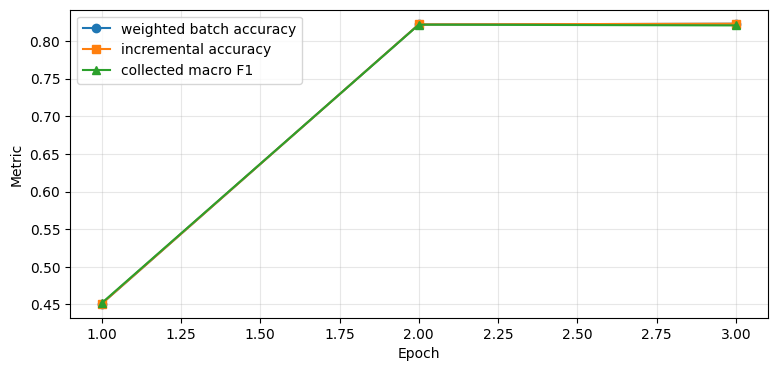

In [5]:
def make_battery(*, pretrained=False):
    model = CIFAR10ResNet(pretrained=pretrained)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
    plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=0
    )
    unfreezing = ProgressiveUnfreezing()
    scheduler = LearningRateScheduler(
        plateau,
        interval="epoch",
        phase="validation",
        metric="macro_f1",
    )
    checkpoint = ModelCheckpoint(
        phase="validation",
        metric="macro_f1",
        mode="max",
        save_dir=str(CHECKPOINT_DIR),
        save_path="{epoch}-{macro_f1:.3f}.pth",
        save_top_k=2,
    )
    running_accuracy = RunningAccuracy()
    battery = Battery(
        model,
        device=DEVICE,
        optimizer=optimizer,
        callbacks=[unfreezing, scheduler, checkpoint],
        metrics={
            "batch_accuracy": batch_accuracy,
            "running_accuracy": running_accuracy,
            "macro_f1": CollectedMetric(macro_f1),
        },
    )
    return battery, model, unfreezing, checkpoint, running_accuracy


battery, model, unfreezing, checkpoint, running_accuracy = make_battery(pretrained=True)
history = battery.fit(
    train_loader,
    validation_loader,
    epochs=INITIAL_EPOCHS,
    verbose=1,
)

epochs = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(9, 4))
plt.plot(
    epochs,
    history["val_metrics"]["batch_accuracy"],
    marker="o",
    label="weighted batch accuracy",
)
plt.plot(
    epochs,
    history["val_metrics"]["running_accuracy"],
    marker="s",
    label="incremental accuracy",
)
plt.plot(
    epochs,
    history["val_metrics"]["macro_f1"],
    marker="^",
    label="collected macro F1",
)
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Inspect and explicitly save full training state

Each top-k file contains model, optimizer, callback, metric, epoch, optimizer-step, and history state. The schema marker identifies this structure. `Battery.save_checkpoint()` uses the same atomic full-state format independently of metric ranking.

In [6]:
ranked_checkpoints = sorted(CHECKPOINT_DIR.glob("epoch=*.pth"))
print("Top-k checkpoint files:")
for path in ranked_checkpoints:
    print(f"  {path.name}")

best_payload = torch.load(checkpoint.best_model_path, weights_only=True)
print(f"Checkpoint schema: {best_payload['__torch_batteries_checkpoint__']}")
print(f"Checkpoint fields: {sorted(best_payload)}")

manual_checkpoint = CHECKPOINT_DIR / "manual-training-state.pth"
battery.save_checkpoint(manual_checkpoint)
print(f"Explicit checkpoint: {manual_checkpoint}")

Top-k checkpoint files:
  epoch=2-macro_f1=0.822.pth
  epoch=3-macro_f1=0.821.pth
Checkpoint schema: 2
Checkpoint fields: ['__torch_batteries_checkpoint__', 'callbacks', 'data_pack', 'epoch', 'metrics', 'model', 'optimizer', 'optimizer_step_idx', 'results']
Explicit checkpoint: checkpoints/cifar10-transfer/manual-training-state.pth


## 7. Restore and resume with both epoch modes

A fresh model, optimizer, scheduler, metrics, and identically ordered callback list are required for strict full-state restoration.

- `resume_epochs_mode="total"` interprets `epochs` as the desired total history length. Restoring epoch 3 and requesting 5 trains epochs 4 and 5.
- `resume_epochs_mode="additional"` interprets `epochs` as new work. Restoring the five-epoch checkpoint and requesting 2 trains epochs 6 and 7.

In [7]:
restored_battery, restored_model, restored_unfreezing, _, restored_metric = (
    make_battery()
)
restored_battery.load_checkpoint(manual_checkpoint)
print(f"Restored callback is unfrozen: {restored_unfreezing.unfrozen}")
print(f"Restored metric samples: {restored_metric.samples}")

total_history = restored_battery.fit(
    train_loader,
    validation_loader,
    epochs=5,
    verbose=1,
    resume_epochs_mode="total",
)
after_total_checkpoint = CHECKPOINT_DIR / "after-total-resume.pth"
restored_battery.save_checkpoint(after_total_checkpoint)

(
    additional_battery,
    additional_model,
    additional_unfreezing,
    additional_checkpoint,
    _,
) = make_battery()
additional_history = additional_battery.fit(
    train_loader,
    validation_loader,
    epochs=2,
    verbose=1,
    resume_from=after_total_checkpoint,
    resume_epochs_mode="additional",
)

print(f"History after total resume: {len(total_history['train_loss'])} epochs")
print(
    f"History after additional resume: {len(additional_history['train_loss'])} epochs"
)
print(f"Additional model is unfrozen: {additional_unfreezing.unfrozen}")

Restored callback is unfrozen: True
Restored metric samples: 1000


Epoch 7/7 [Validation]: 100%|██████████| 16/16 [00:00<00:00, 42.21it/s, Loss=0.5189, Batch_accuracy=0.8530]


History after total resume: 5 epochs
History after additional resume: 7 epochs
Additional model is unfrozen: True


## 8. Load raw model weights

`load_checkpoint()` automatically distinguishes a raw model state dictionary from the structured full checkpoint. Raw loading is strict and emits a warning because optimizer, callback, metric, epoch, and history state cannot be restored.

For metric-selected raw files, configure `ModelCheckpoint(..., save_weights_only=True)`. This is an explicit alternative to its full-state default and is suitable for inference-only artifacts.

In [8]:
raw_weights_path = CHECKPOINT_DIR / "resnet18-cifar10-weights.pth"
torch.save(additional_model.state_dict(), raw_weights_path)

raw_model = CIFAR10ResNet(pretrained=False)
raw_battery = Battery(raw_model, device=DEVICE)
raw_battery.load_checkpoint(raw_weights_path)
print(f"Loaded raw weights from: {raw_weights_path}")

weights_only_checkpoint = ModelCheckpoint(
    phase="validation",
    metric="macro_f1",
    mode="max",
    save_dir=str(CHECKPOINT_DIR),
    save_path="best-inference-weights.pth",
    save_weights_only=True,
)
print(
    "Explicit inference-only callback configuration: "
    f"{type(weights_only_checkpoint).__name__}"
)

[torch_batteries] WARNING: Raw model state detected at checkpoints/cifar10-transfer/resnet18-cifar10-weights.pth; training state was not restored.


Loaded raw weights from: checkpoints/cifar10-transfer/resnet18-cifar10-weights.pth
Explicit inference-only callback configuration: ModelCheckpoint


## 9. Evaluate and concatenate structured predictions

Longer fine-tuning can eventually overfit a bounded subset, so evaluation restores the checkpoint with the best validation macro F1 instead of assuming the final epoch is best. For prediction, `move_to_cpu=True` recursively detaches accelerator tensors, while `concatenate=True` combines matching tensors across batches. The result remains a dictionary containing logits, probabilities, and predicted classes.

Evaluating validation-best checkpoint: checkpoints/cifar10-transfer/epoch=7-macro_f1=0.854.pth


Epoch 1/1 [Test]: 100%|██████████| 16/16 [00:00<00:00, 43.23it/s, Loss=0.4788, Batch_accuracy=0.8480]


Test macro F1: 0.848


Epoch 1/1 [Predict]: 100%|██████████| 3/3 [00:00<00:00, 35.81it/s]


Structured keys: ['classes', 'logits', 'probabilities']
Logit shape: (12, 10)
Prediction device: cpu


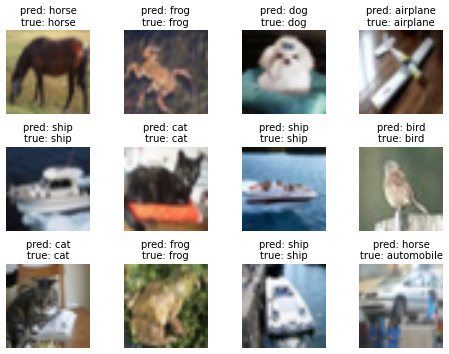

In [9]:
evaluation_battery, evaluation_model, _, _, _ = make_battery()
evaluation_battery.load_checkpoint(additional_checkpoint.best_model_path)
print(f"Evaluating validation-best checkpoint: {additional_checkpoint.best_model_path}")
test_result = evaluation_battery.test(test_loader, verbose=1)
print(f"Test macro F1: {test_result['test_metrics']['macro_f1']:.3f}")

prediction_indices = test_indices[:12]
prediction_loader = DataLoader(Subset(test_data, prediction_indices), batch_size=4)
prediction_result = evaluation_battery.predict(
    prediction_loader,
    verbose=1,
    move_to_cpu=True,
    concatenate=True,
)["predictions"]

print(f"Structured keys: {sorted(prediction_result)}")
print(f"Logit shape: {tuple(prediction_result['logits'].shape)}")
print(f"Prediction device: {prediction_result['classes'].device}")

class_names = test_data.classes
figure, axes = plt.subplots(3, 4, figsize=(8, 6), dpi=60)
for axis, dataset_index, predicted_class in zip(
    axes.flat,
    prediction_indices,
    prediction_result["classes"].tolist(),
    strict=True,
):
    image, target = test_data[dataset_index]
    display_image = image.permute(1, 2, 0).numpy()
    display_image = display_image * np.array(normalization.std)
    display_image = display_image + np.array(normalization.mean)
    axis.imshow(np.clip(display_image, 0, 1))
    axis.set_title(f"pred: {class_names[predicted_class]}\ntrue: {class_names[target]}")
    axis.axis("off")
plt.tight_layout()
plt.show()